In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

# Imports

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import pandas as pd
import geopandas as gpd
import contextily as ctx
import pandas as pd
import os

import sys
import os

%matplotlib widget
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *
from shapely.geometry import Point
from shapely.geometry import LineString, Point
import numpy as np

os.chdir('/home/sandbox/personal-repos/DA-3507/dump')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../lib')))
from custom_pandas import *

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


## Query the surveys

In [3]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[20]].copy()

## Query the geometries

In [4]:
report_bc.db.set_query(query_SurveyH3Aggregation_byReport(report_table = '#TempReport'))
agg_segments =report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

## Isolate a single survey

In [5]:
l = 1
surveys = segments['SurveyId'].unique()
survey = segments[segments['SurveyId'] == surveys[l]]
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

/tmp/ipykernel_32670/555364653.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)


## Prepare the countour geometry

In [6]:
contour = agg_segments[agg_segments['SurveyId'] == surveys[l]]
contour['Breadcrumb_wkt'] = contour['Breadcrumb'].apply(wkt.loads)
contour_gdf = gpd.GeoDataFrame(contour, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
contour_gdf = contour_gdf.to_crs(utm_crs)
contour_gdf['offset'] = contour_gdf.geometry.buffer(5, cap_style=2)


/tmp/ipykernel_32670/3952355739.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contour['Breadcrumb_wkt'] = contour['Breadcrumb'].apply(wkt.loads)


## Create a evenly spaced grid

In [7]:
def sample_linearly(line, distance):
    if not isinstance(line, LineString):
        return []
    length = line.length
    # Compute evenly spaced distances along the line, always include endpoints
    num_points = int(np.floor(length / distance)) + 1
    if np.isclose(num_points * distance, length):
        distances = np.linspace(0, length, num=num_points + 1)
    else:
        distances = np.arange(0, length, distance)
        if length not in distances:
            distances = np.append(distances, length)
    return [line.interpolate(d) for d in distances]

survey_gdf['EvenlySpaced'] = survey_gdf.geometry.apply(lambda line: sample_linearly(line, 10))
#survey_gdf['EvenlySpaced'] = survey_gdf.geometry.segmentize(10)

In [8]:
# Create the geometry from list of points, plot the result
survey_gdf['EvenlySpacedLine'] = survey_gdf['EvenlySpaced'].apply(lambda pts: LineString(pts) if len(pts) >= 2 else None)
#survey_gdf['EvenlySpacedLine'] = survey_gdf['EvenlySpaced']

In [9]:
survey_gdf

,ReportId,SurveyId,Breadcrumb,Order,Breadcrumb_wkt,EvenlySpaced,EvenlySpacedLine
199,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21510595 53.49840993, -2.215151...",102,"LINESTRING (552065.466 5928003.532, 552062.502...","[POINT (552065.4657829654 5928003.531822461), ...",LINESTRING (552065.4657829654 5928003.53182246...
200,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.20532229 53.50000572, -2.204370...",76,"LINESTRING (552712.467 5928188.252, 552775.186...","[POINT (552712.4673925138 5928188.251725099), ...",LINESTRING (552712.4673925138 5928188.25172509...
201,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.19458773 53.50370673, -2.194759...",3,"LINESTRING (553419.844 5928607.974, 553408.575...","[POINT (553419.8444436463 5928607.974346476), ...",LINESTRING (553419.8444436463 5928607.97434647...
202,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.2129258 53.50214692, -2.2125275...",26,"LINESTRING (552205.491 5928420.860, 552232.430...","[POINT (552205.4909650983 5928420.859607701), ...",LINESTRING (552205.4909650983 5928420.85960770...
203,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.20663262 53.50291741, -2.206757...",78,"LINESTRING (552621.947 5928511.203, 552613.604...","[POINT (552621.9465399134 5928511.20328342), P...",LINESTRING (552621.9465399134 5928511.20328342...
...,...,...,...,...,...,...,...
341,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21915149 53.50139427, -2.219146...",143,"LINESTRING (551793.475 5928332.586, 551793.480...","[POINT (551793.4748290036 5928332.586438067), ...",LINESTRING (551793.4748290036 5928332.58643806...
342,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21240623 53.4978934, -2.2123096...",50,"LINESTRING (552245.182 5927948.044, 552251.747...","[POINT (552245.1817566864 5927948.044389725), ...",LINESTRING (552245.1817566864 5927948.04438972...
343,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.20628369 53.50262492, -2.204837...",42,"LINESTRING (552645.452 5928478.922, 552743.317...","[POINT (552645.4520897374 5928478.922019498), ...",LINESTRING (552645.4520897374 5928478.92201949...
344,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21149765 53.5015768, -2.2116935...",29,"LINESTRING (552300.918 5928358.482, 552287.646...","[POINT (552300.9180493142 5928358.481897805), ...",LINESTRING (552300.9180493142 5928358.48189780...


# Create a line perpendicular line at each vertex

In [10]:
import numpy as np
from shapely.geometry import LineString, Point

def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def perpendicular_vector(dx, dy):
    """ Returns a perpendicular vector (to the left of direction of travel). """
    return np.array([-dy, dx])

def perp_lines_at_vertices(line, length=10):
    """Generate perpendicular lines at each vertex of a LineString."""
    coords = list(line.coords)
    perps = []
    n = len(coords)

    for i, (x, y) in enumerate(coords):
        # For endpoints, use segment direction from second/previous point
        if n < 2:
            continue  # Not enough points
        elif i == 0:
            x2, y2 = coords[i + 1]
            dx, dy = x2 - x, y2 - y
        elif i == n - 1:
            x1, y1 = coords[i - 1]
            dx, dy = x - x1, y - y1
        else:
            # Average both directions for a smoother result
            x1, y1 = coords[i - 1]
            x2, y2 = coords[i + 1]
            dx1, dy1 = x - x1, y - y1
            dx2, dy2 = x2 - x, y2 - y
            dx, dy = unit_vector(np.array([dx1, dy1])) + unit_vector(np.array([dx2, dy2]))
            if np.linalg.norm([dx, dy]) == 0:  # colinear back-to-back turn, fallback
                dx, dy = -dy1, dx1

        direction = unit_vector(np.array([dx, dy]))
        perp = perpendicular_vector(*direction)
        midpoint = np.array([x, y])
        half = (length / 2.0) * perp
        line_pts = [midpoint - half, midpoint + half]
        perps.append(LineString(line_pts))

    return perps

perp_lines = []
for geom in survey_gdf.EvenlySpacedLine:
    if isinstance(geom, LineString):
        perp_lines.extend(perp_lines_at_vertices(geom, length=20))

perp_gdf = gpd.GeoDataFrame(geometry=perp_lines, crs=survey_gdf.crs if hasattr(survey_gdf, 'crs') else None)
perp_gdf.reset_index(drop=True)

,geometry
0,"LINESTRING (552055.729 5928005.813, 552075.202..."
1,"LINESTRING (552053.336 5927993.360, 552073.254..."
2,"LINESTRING (552059.192 5927979.238, 552075.396..."
3,"LINESTRING (552068.205 5927970.875, 552081.108..."
4,"LINESTRING (552076.246 5927964.464, 552088.709..."
...,...
2960,"LINESTRING (552509.149 5928169.935, 552516.206..."
2961,"LINESTRING (552501.713 5928160.661, 552521.636..."
2962,"LINESTRING (552521.512 5928142.839, 552515.133..."
2963,"LINESTRING (552527.969 5928152.640, 552509.285..."


# Create the intersection for getting the number of passes

In [11]:
survey_gdf.set_geometry(survey_gdf.EvenlySpacedLine)

,ReportId,SurveyId,Breadcrumb,Order,Breadcrumb_wkt,EvenlySpaced,EvenlySpacedLine
199,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21510595 53.49840993, -2.215151...",102,"LINESTRING (552065.466 5928003.532, 552063.295...","[POINT (552065.4657829654 5928003.531822461), ...",LINESTRING (552065.4657829654 5928003.53182246...
200,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.20532229 53.50000572, -2.204370...",76,"LINESTRING (552712.467 5928188.252, 552721.099...","[POINT (552712.4673925138 5928188.251725099), ...",LINESTRING (552712.4673925138 5928188.25172509...
201,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.19458773 53.50370673, -2.194759...",3,"LINESTRING (553419.844 5928607.974, 553412.496...","[POINT (553419.8444436463 5928607.974346476), ...",LINESTRING (553419.8444436463 5928607.97434647...
202,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.2129258 53.50214692, -2.2125275...",26,"LINESTRING (552205.491 5928420.860, 552210.460...","[POINT (552205.4909650983 5928420.859607701), ...",LINESTRING (552205.4909650983 5928420.85960770...
203,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.20663262 53.50291741, -2.206757...",78,"LINESTRING (552621.947 5928511.203, 552613.056...","[POINT (552621.9465399134 5928511.20328342), P...",LINESTRING (552621.9465399134 5928511.20328342...
...,...,...,...,...,...,...,...
341,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21915149 53.50139427, -2.219146...",143,"LINESTRING (551793.475 5928332.586, 551793.477...","[POINT (551793.4748290036 5928332.586438067), ...",LINESTRING (551793.4748290036 5928332.58643806...
342,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21240623 53.4978934, -2.2123096...",50,"LINESTRING (552245.182 5927948.044, 552249.381...","[POINT (552245.1817566864 5927948.044389725), ...",LINESTRING (552245.1817566864 5927948.04438972...
343,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.20628369 53.50262492, -2.204837...",42,"LINESTRING (552645.452 5928478.922, 552650.313...","[POINT (552645.4520897374 5928478.922019498), ...",LINESTRING (552645.4520897374 5928478.92201949...
344,C4AE9B4A-C0DD-EB7E-EDAA-3A2118AA627C,9F55B878-BB70-8183-E348-3A2112850162,"LINESTRING (-2.21149765 53.5015768, -2.2116935...",29,"LINESTRING (552300.918 5928358.482, 552296.236...","[POINT (552300.9180493142 5928358.481897805), ...",LINESTRING (552300.9180493142 5928358.48189780...


In [12]:
intersection_results = gpd.sjoin(perp_gdf, survey_gdf, how='right', predicate='intersects')
intersection_results.columns


Index(['index_left', 'ReportId', 'SurveyId', 'Breadcrumb', 'Order',
       'Breadcrumb_wkt', 'EvenlySpaced', 'EvenlySpacedLine'],
      dtype='object')

In [13]:
intersections = intersection_results.groupby('index_left').size()
intersections


index_left
0       2
1       2
2       2
3       2
4       1
       ..
2960    1
2961    1
2962    1
2963    1
2964    2
Length: 2965, dtype: int64

In [14]:
# Merge perp_gdf with intersections to append the number of passes to each perpendicular line
perp_gdf = perp_gdf.merge(intersections.rename('num_passes'), left_index=True, right_index=True, how='left')

# Plotting

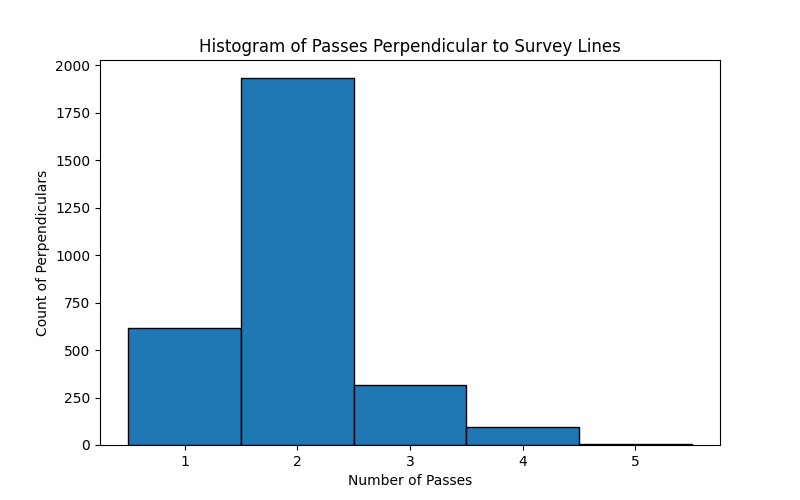

In [15]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(8, 5))
# Plot histogram of number of passes per perpendicular line
plt.hist(intersections.values, bins=range(intersections.min(), intersections.max() + 2), edgecolor='black', align='left')
plt.xlabel('Number of Passes')
plt.ylabel('Count of Perpendiculars')
plt.title('Histogram of Passes Perpendicular to Survey Lines')
plt.show()


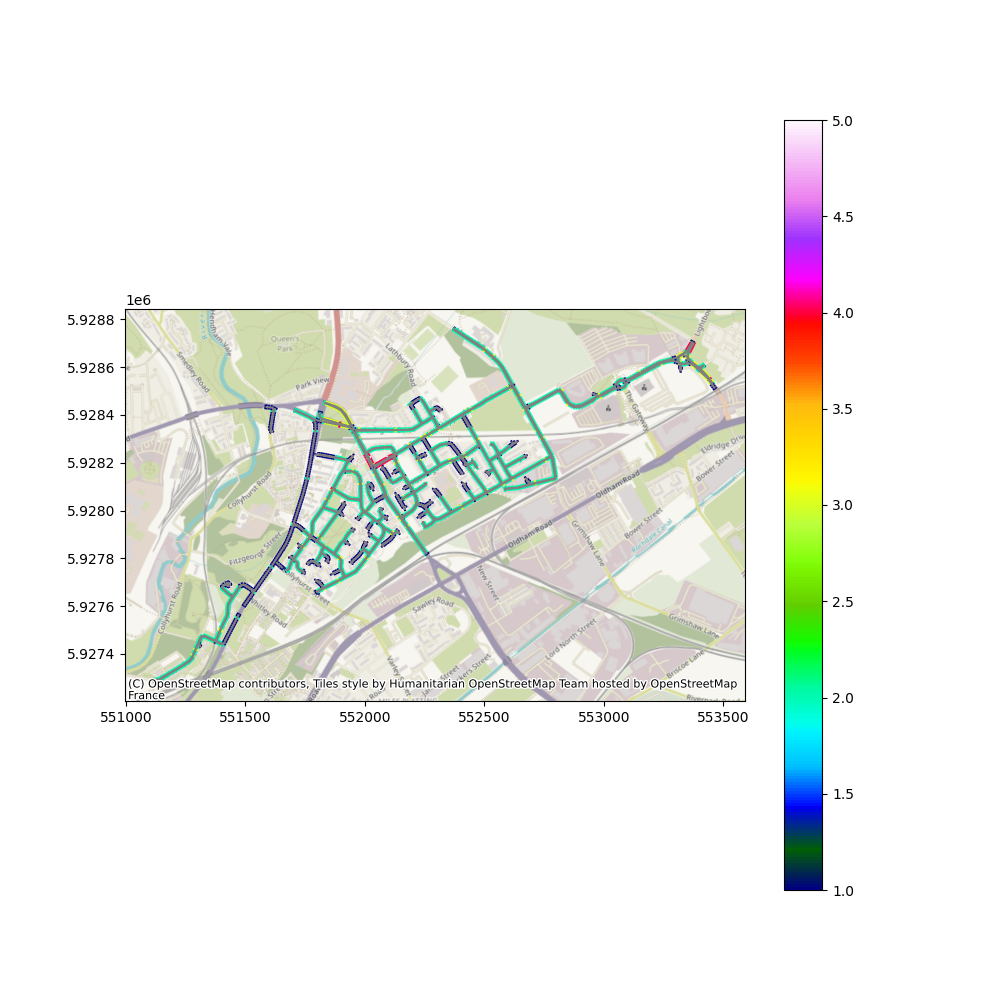

In [16]:
import contextily as ctx
import matplotlib as mpl
import numpy as np

fig, ax2 = plt.subplots(figsize=(10, 10))   

perp_gdf.plot(ax = ax2,
    figsize=(10, 10),
    column='num_passes',
    cmap='gist_ncar',
    legend=True)
contour_gdf.offset.plot(ax=ax2, color='red', alpha=0.5)
survey_gdf.geometry.plot(ax=ax2, color='gray')

# Add basemap
if perp_gdf.crs is not None:
    # contextily requires Web Mercator for the basemap
    try:
        ax2= ctx.add_basemap(ax2, crs=perp_gdf.crs.to_string() if hasattr(perp_gdf.crs, "to_string") else perp_gdf.crs)
    except Exception:
        # fallback if .to_string() is not available
        ax2 = ctx.add_basemap(ax2, crs=perp_gdf.crs)
else:
    # If CRS is None, skip basemap or handle accordingly
    pass
